# Vesper Capital — Combined Long/Short Model

Runs both a **long model** and a **short model** independently using the validated walk-forward architecture. Analyzes each model separately before deciding whether to combine them in the capital simulation.

**Capital simulation design:**
- Each signal opens a **24-hour trade** (matches model target horizon exactly)
- Multiple signals can be open simultaneously
- Transaction costs on entry and exit only
- Short model only used if statistically significant (cell 6 decides)

**Short model status:** Not statistically significant with current 200-wallet pool (p=0.617 non-November). Will be re-evaluated after wallet selection redesign.

## 1. Configuration

In [12]:
from claude_refactor_core_utils import *
from dateutil.relativedelta import relativedelta
from datetime import date, timedelta
import pandas as pd
import numpy as np
import os
import calendar
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Window boundaries ──────────────────────────────────────────
FULL_START       = date(2023, 1, 1)
FULL_END         = date(2024, 12, 31)
TARGET_HORIZON_H = 24
MIN_DELTA_ETH    = 0.005
ROLLING_WINDOWS  = [6, 24, 72, 168]

# ── Capital simulation ─────────────────────────────────────────
INITIAL_CAPITAL   = 100_000
POSITION_PCT      = 0.25      # fraction of capital per signal
TRANSACTION_COST  = 0.001     # 0.1% round-trip
MAX_POSITION_PCT  = 0.50
HOLD_HOURS        = 24        # match model target horizon

# ── Conviction scaling & cooldown (tuned by param search) ─
MIN_HOURS_BETWEEN_ENTRIES = 48
CONVICTION_WINDOW         = 24
MAX_SIZE_MULTIPLIER       = 1.0
MIN_CONVICTION_TO_ENTER   = 0.3
# Note: run cell 7 (param search) to optimise these automatically

# ── Walk-forward config ────────────────────────────────────────
TRAIN_MONTHS      = 4
VAL_MONTHS        = 2
THRESHOLD_SEARCH  = np.arange(0.0, 2.0, 0.05)
MIN_VAL_ACTIVE    = 10

# ── Model params ───────────────────────────────────────────────
MODEL_PARAMS = dict(
    n_estimators=200, max_depth=3, learning_rate=0.02,
    subsample=0.6, colsample_bytree=0.3, min_child_weight=50,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42,
    n_jobs=-1, verbosity=0
)

# ── Files ──────────────────────────────────────────────────────
HOURLY_BALANCE_CSV   = '/home/colin/projects/blockchain_alpha/data/balance_store_hourly_top200.csv'
DAILY_SKILL_CSV      = '/home/colin/projects/blockchain_alpha/data/random_10k_skill_results.csv'
COMBINED_RESULTS_CSV = '/home/colin/projects/blockchain_alpha/data/combined_model_results.csv'

print(f"Window: {FULL_START} to {FULL_END}")
print(f"Initial capital: ${INITIAL_CAPITAL:,.0f}")
print(f"Position sizing: {POSITION_PCT*100:.0f}% per signal, max {MAX_POSITION_PCT*100:.0f}%")
print(f"Hold period: {HOLD_HOURS} hours (matches model target horizon)")
print(f"Transaction cost: {TRANSACTION_COST*100:.1f}% round-trip")


Window: 2023-01-01 to 2024-12-31
Initial capital: $100,000
Position sizing: 25% per signal, max 50%
Hold period: 24 hours (matches model target horizon)
Transaction cost: 0.1% round-trip


## 2. Load data

In [2]:
print("Loading hourly balance store...")
raw = pd.read_csv(HOURLY_BALANCE_CSV)
raw['date']        = pd.to_datetime(raw['date'], format='mixed').dt.floor('h')
raw['address']     = raw['address'].str.lower().str.strip()
raw['balance_wei'] = pd.to_numeric(raw['balance_wei'], errors='coerce').fillna(0).astype('int64')

hourly = (
    raw.sort_values(['address','date','block_number'])
    .groupby(['address','date'], as_index=False).tail(1)
    .reset_index(drop=True)
)
hourly['balance_eth'] = hourly['balance_wei'] / 1e18
hourly = hourly.sort_values(['address','date'])
hourly['delta_eth'] = hourly.groupby('address')['balance_eth'].diff()
hourly['action_raw'] = hourly['delta_eth'].apply(
    lambda d: 1 if d > MIN_DELTA_ETH else (-1 if d < -MIN_DELTA_ETH else 0)
)
wallet_list = sorted(hourly['address'].unique().tolist())

print("Loading hourly prices...")
df_price = load_eth_usd_cryptocompare(
    start=str(FULL_START), end=str(FULL_END), interval='1h'
)
df_price['date'] = pd.to_datetime(df_price['date']).dt.floor('h')
df_price = df_price.sort_values('date').reset_index(drop=True)
df_price['fwd_return'] = (
    df_price['close'].shift(-TARGET_HORIZON_H) - df_price['close']
) / df_price['close'] * 100
df_price['ret_1h']      = df_price['close'].pct_change(1)  * 100
df_price['ret_4h']      = df_price['close'].pct_change(4)  * 100
df_price['ret_24h']     = df_price['close'].pct_change(24) * 100
df_price['ret_72h']     = df_price['close'].pct_change(72) * 100
df_price['vol_24h']     = df_price['ret_1h'].rolling(24).std()
df_price['vol_72h']     = df_price['ret_1h'].rolling(72).std()
df_price['hour_of_day'] = df_price['date'].dt.hour
df_price['day_of_week'] = df_price['date'].dt.dayofweek

print(f"Wallets: {len(wallet_list)}, Hours: {len(df_price):,}")


Loading hourly balance store...
Loading hourly prices...
Wallets: 201, Hours: 17,521


## 3. Build feature matrix

In [3]:
print("Building feature matrix...")

action_wide = hourly.pivot_table(
    index='date', columns='address', values='action_raw', aggfunc='first'
).fillna(0)
delta_wide = hourly.pivot_table(
    index='date', columns='address', values='delta_eth', aggfunc='first'
).fillna(0)

wallet_features = pd.DataFrame(index=action_wide.index)
for addr in wallet_list:
    if addr not in action_wide.columns:
        continue
    short = addr[:10]
    act   = action_wide[addr]
    dlt   = delta_wide[addr]
    wallet_features[f'{short}_action']     = act
    wallet_features[f'{short}_wtd_action'] = dlt * act.abs()
    for w in ROLLING_WINDOWS:
        wallet_features[f'{short}_buy_pressure_{w}h'] = (
            (act > 0).astype(float).rolling(w, min_periods=1).mean()
        )
    wallet_features[f'{short}_max_buy_24h'] = dlt.clip(lower=0).rolling(24, min_periods=1).max()

buy_matrix  = (action_wide > 0).astype(float)
sell_matrix = (action_wide < 0).astype(float)
wallet_features['pool_buy_fraction']   = buy_matrix.mean(axis=1)
wallet_features['pool_sell_fraction']  = sell_matrix.mean(axis=1)
wallet_features['pool_net_fraction']   = (
    wallet_features['pool_buy_fraction'] - wallet_features['pool_sell_fraction']
)
buy_pressure  = delta_wide.clip(lower=0).sum(axis=1)
sell_pressure = delta_wide.clip(upper=0).abs().sum(axis=1)
total_vol     = buy_pressure + sell_pressure + 1e-9
wallet_features['pool_net_pressure_eth'] = (buy_pressure - sell_pressure) / total_vol
for w in [6, 24, 72]:
    wallet_features[f'pool_buy_fraction_{w}h'] = (
        wallet_features['pool_buy_fraction'].rolling(w, min_periods=1).mean()
    )
    wallet_features[f'pool_net_pressure_{w}h'] = (
        wallet_features['pool_net_pressure_eth'].rolling(w, min_periods=1).mean()
    )
n_active = (action_wide != 0).sum(axis=1).clip(lower=1)
n_agree  = buy_matrix.sum(axis=1).combine(sell_matrix.sum(axis=1), max)
wallet_features['pool_conviction'] = n_agree / n_active

feature_df = wallet_features.reset_index().rename(columns={'date':'timestamp'})
price_cols  = ['date','close','fwd_return',
               'ret_1h','ret_4h','ret_24h','ret_72h',
               'vol_24h','vol_72h','hour_of_day','day_of_week']
full_df = feature_df.merge(
    df_price[price_cols].rename(columns={'date':'timestamp'}),
    on='timestamp', how='inner'
).dropna(subset=['fwd_return']).reset_index(drop=True)

EXCLUDE_COLS = ['timestamp','close','fwd_return']
FEATURE_COLS = [c for c in full_df.columns if c not in EXCLUDE_COLS]
print(f"Feature matrix: {full_df.shape}, Features: {len(FEATURE_COLS)}")


Building feature matrix...
Feature matrix: (17497, 1429), Features: 1426


## 4. Walk-forward fold schedule

In [4]:
folds = []
cursor = FULL_START

while True:
    train_start = cursor
    train_end_month = train_start.month + TRAIN_MONTHS + VAL_MONTHS - 1
    train_end = date(
        train_start.year + (train_end_month - 1) // 12,
        (train_end_month - 1) % 12 + 1,
        calendar.monthrange(
            train_start.year + (train_end_month - 1) // 12,
            (train_end_month - 1) % 12 + 1
        )[1]
    )
    test_start = train_end + timedelta(days=1)
    test_end   = date(
        test_start.year + (test_start.month - 1) // 12,
        test_start.month,
        calendar.monthrange(test_start.year, test_start.month)[1]
    )
    if test_end > FULL_END:
        break
    folds.append({
        'train_start': train_start, 'train_end': train_end,
        'test_start':  test_start,  'test_end':  test_end,
    })
    next_month = cursor.month + 1
    next_year  = cursor.year + (next_month - 1) // 12
    next_month = (next_month - 1) % 12 + 1
    cursor = date(next_year, next_month, 1)

print(f"Walk-forward folds: {len(folds)}")
for i, f in enumerate(folds):
    print(f"  Fold {i+1:2d}: train {f['train_start']} to {f['train_end']}  "
          f"test {f['test_start']} to {f['test_end']}")


Walk-forward folds: 18
  Fold  1: train 2023-01-01 to 2023-06-30  test 2023-07-01 to 2023-07-31
  Fold  2: train 2023-02-01 to 2023-07-31  test 2023-08-01 to 2023-08-31
  Fold  3: train 2023-03-01 to 2023-08-31  test 2023-09-01 to 2023-09-30
  Fold  4: train 2023-04-01 to 2023-09-30  test 2023-10-01 to 2023-10-31
  Fold  5: train 2023-05-01 to 2023-10-31  test 2023-11-01 to 2023-11-30
  Fold  6: train 2023-06-01 to 2023-11-30  test 2023-12-01 to 2023-12-31
  Fold  7: train 2023-07-01 to 2023-12-31  test 2024-01-01 to 2024-01-31
  Fold  8: train 2023-08-01 to 2024-01-31  test 2024-02-01 to 2024-02-29
  Fold  9: train 2023-09-01 to 2024-02-29  test 2024-03-01 to 2024-03-31
  Fold 10: train 2023-10-01 to 2024-03-31  test 2024-04-01 to 2024-04-30
  Fold 11: train 2023-11-01 to 2024-04-30  test 2024-05-01 to 2024-05-31
  Fold 12: train 2023-12-01 to 2024-05-31  test 2024-06-01 to 2024-06-30
  Fold 13: train 2024-01-01 to 2024-06-30  test 2024-07-01 to 2024-07-31
  Fold 14: train 2024-02-01 

## 5. Walk-forward — Long & Short models

In [5]:
def run_walkforward(full_df, folds, feature_cols, target_col,
                    model_params, threshold_search, min_val_active):
    results = []
    for fold_idx, fold in enumerate(folds):
        val_start        = fold['train_end'] - relativedelta(months=2) + relativedelta(days=1)
        train_end_actual = val_start - relativedelta(days=1)

        train_mask = ((full_df['timestamp'].dt.date >= fold['train_start']) &
                      (full_df['timestamp'].dt.date <= train_end_actual))
        val_mask   = ((full_df['timestamp'].dt.date >= val_start) &
                      (full_df['timestamp'].dt.date <= fold['train_end']))
        test_mask  = ((full_df['timestamp'].dt.date >= fold['test_start']) &
                      (full_df['timestamp'].dt.date <= fold['test_end']))

        train_fold = full_df[train_mask].copy()
        val_fold   = full_df[val_mask].copy()
        test_fold  = full_df[test_mask].copy()

        if len(train_fold) < 200 or len(val_fold) < 100 or len(test_fold) < 50:
            continue

        X_train = train_fold[feature_cols].values
        y_train = train_fold[target_col].values
        X_val   = val_fold[feature_cols].values
        y_val   = val_fold[target_col].values
        X_test  = test_fold[feature_cols].values

        model_fold = xgb.XGBRegressor(**model_params)
        model_fold.fit(X_train, y_train)

        y_pred_val  = model_fold.predict(X_val)
        y_pred_test = model_fold.predict(X_test)

        best_threshold = 0.0
        best_val_edge  = -999
        base_val_mean  = y_val.mean()

        for threshold in threshold_search:
            pos   = (y_pred_val > threshold).astype(float)
            n_act = int(pos.sum())
            if n_act < min_val_active:
                continue
            active = pd.Series(pos * y_val)[pos > 0]
            edge   = active.mean() - base_val_mean
            if edge > best_val_edge:
                best_val_edge  = edge
                best_threshold = threshold

        results.append({
            'fold':          fold_idx + 1,
            'test_month':    fold['test_start'].strftime('%Y-%m'),
            'test_start':    fold['test_start'],
            'test_end':      fold['test_end'],
            'threshold':     best_threshold,
            'val_edge':      best_val_edge,
            'timestamps':    test_fold['timestamp'].values,
            'actual_returns':test_fold['fwd_return'].values,
            'close':         test_fold['close'].values,
            'y_pred':        y_pred_test,
            'positions':     (y_pred_test > best_threshold).astype(float),
        })

    return results

full_df['fwd_return_inv'] = -full_df['fwd_return']

print("Running LONG model walk-forward...")
long_results  = run_walkforward(
    full_df, folds, FEATURE_COLS, 'fwd_return',
    MODEL_PARAMS, THRESHOLD_SEARCH, MIN_VAL_ACTIVE
)
print(f"  {len(long_results)} folds completed")

print("Running SHORT model walk-forward...")
short_results = run_walkforward(
    full_df, folds, FEATURE_COLS, 'fwd_return_inv',
    MODEL_PARAMS, THRESHOLD_SEARCH, MIN_VAL_ACTIVE
)
print(f"  {len(short_results)} folds completed")
print("Both models complete.")


Running LONG model walk-forward...
  18 folds completed
Running SHORT model walk-forward...
  18 folds completed
Both models complete.


## 5b. Optional: 1h walk-forward

Run this to get `long_results_1h` and `pos_1h_lookup` for use in the behavior-driven exit simulation below.

Uses `full_df` and `folds` already in memory — no data reload needed.

In [6]:
# ============================================================
# 1h walk-forward — run after 24h walk-forward above
# Uses same full_df, folds, FEATURE_COLS already in memory
# Wallet features already shifted 1h (D21) from feature build
# ============================================================

THRESHOLD_SEARCH_1H = np.arange(0.0, 0.5, 0.01)
MIN_THRESHOLD_1H    = 0.05

# Add 1h target column if not present
if 'fwd_1h' not in full_df.columns:
    price_1h = load_eth_usd_cryptocompare(
        start=str(FULL_START), end=str(FULL_END), interval='1h'
    )
    price_1h['date'] = pd.to_datetime(price_1h['date']).dt.floor('h')
    price_1h = price_1h.sort_values('date').reset_index(drop=True)
    price_1h['fwd_1h'] = (
        price_1h['close'].shift(-1) - price_1h['close']
    ) / price_1h['close'] * 100
    full_df = full_df.merge(
        price_1h[['date','fwd_1h']].rename(columns={'date':'timestamp'}),
        on='timestamp', how='left'
    )
    print("Added fwd_1h column to full_df")

# Run 1h walk-forward using same run_walkforward function
# (target column = fwd_1h instead of fwd_return)
full_df_1h = full_df.copy()
full_df_1h['fwd_return'] = full_df_1h['fwd_1h']
full_df_1h = full_df_1h.dropna(subset=['fwd_return']).reset_index(drop=True)

print("Running 1h walk-forward...")
long_results_1h = run_walkforward(
    full_df_1h, folds, FEATURE_COLS, 'fwd_return',
    MODEL_PARAMS, THRESHOLD_SEARCH_1H, MIN_VAL_ACTIVE
)
print(f"{len(long_results_1h)} folds complete.")
print()

# Build 1h position lookup by timestamp for capital simulation
pos_1h_lookup = {}
for r in long_results_1h:
    if r.get('threshold', 0) >= MIN_THRESHOLD_1H:
        for i in range(len(r['timestamps'])):
            ts = pd.Timestamp(r['timestamps'][i])
            pos_1h_lookup[ts] = float(r['positions'][i])

n_1h_signals = sum(1 for v in pos_1h_lookup.values() if v > 0)
print(f"1h signal lookup built: {n_1h_signals:,} active hours across all months")
print("Ready for use in capital simulations below.")


Added fwd_1h column to full_df
Running 1h walk-forward...
18 folds complete.

1h signal lookup built: 360 active hours across all months
Ready for use in capital simulations below.


## 6. Analyze models independently

Evaluate long and short models separately. Sets `USE_SHORT` flag for capital simulation.

In [13]:
from scipy import stats as scipy_stats

def analyze_walkforward_results(results, label="model"):
    rows = []
    for r in results:
        actual  = r['actual_returns']
        pos     = r['positions']
        active  = actual[pos > 0]
        base    = actual.mean()
        rows.append({
            'test_month':  r['test_month'],
            'threshold':   r['threshold'],
            'n_active':    len(active),
            'edge':        active.mean() - base if len(active) > 0 else 0.0,
            'win_rate':    (active > 0).mean() if len(active) > 0 else 0.0,
            'mean_ret':    active.mean() if len(active) > 0 else 0.0,
            'base_mean':   base,
            'beats_bah':   active.mean() > base if len(active) > 0 else False,
            'is_november': pd.Timestamp(r['timestamps'][0]).month == 11,
        })
    df = pd.DataFrame(rows)

    print("=" * 65)
    print(f"WALK-FORWARD RESULTS — {label.upper()}")
    print("=" * 65)
    print(df[['test_month','threshold','n_active','edge',
              'win_rate','beats_bah','is_november']].to_string(index=False))
    print()

    active_df  = df[df['n_active'] >= 5]
    non_nov_df = active_df[~active_df['is_november']]

    print(f"Total folds: {len(df)}  |  Active: {len(active_df)}  |  "
          f"Positive edge: {(active_df['edge']>0).sum()}/{len(active_df)}")
    print()
    if len(non_nov_df) > 0:
        print(f"Non-November ({len(non_nov_df)} folds):")
        print(f"  Mean edge:   {non_nov_df['edge'].mean():+.4f}%/hr")
        print(f"  Win rate:    {non_nov_df['win_rate'].mean():.3f}")
        print(f"  Positive:    {(non_nov_df['edge']>0).sum()} / {len(non_nov_df)}")
    if len(active_df) >= 3:
        t, p = scipy_stats.ttest_1samp(active_df['edge'].values, 0)
        print(f"  T-test all:  t={t:.3f}  p={p:.4f}  "
              f"{'✓ SIGNIFICANT' if p < 0.05 else '✗ not significant'}")
    if len(non_nov_df) >= 3:
        t2, p2 = scipy_stats.ttest_1samp(non_nov_df['edge'].values, 0)
        print(f"  T-test non-Nov: t={t2:.3f}  p={p2:.4f}  "
              f"{'✓ SIGNIFICANT' if p2 < 0.05 else '✗ not significant'}")
    return df

long_df = analyze_walkforward_results(long_results, label="LONG model")


WALK-FORWARD RESULTS — LONG MODEL
test_month  threshold  n_active      edge  win_rate  beats_bah  is_november
   2023-07       0.70        10  2.634239  1.000000       True        False
   2023-08       0.00         0  0.000000  0.000000      False        False
   2023-09       0.15       153  0.055123  0.562092       True        False
   2023-10       0.60        64 -0.051257  0.515625      False        False
   2023-11       0.75        21  2.044194  0.761905       True         True
   2023-12       1.15        17  1.957890  0.764706       True        False
   2024-01       1.20        37  0.536846  0.621622       True        False
   2024-02       1.65         3  1.655474  1.000000       True        False
   2024-03       1.40        43  3.307392  0.767442       True        False
   2024-04       1.75         0  0.000000  0.000000      False        False
   2024-05       1.95        37 -1.173663  0.378378      False        False
   2024-06       1.90         0  0.000000  0.000000   

In [14]:
def analyze_short_model(results):
    rows = []
    for r in results:
        actual_ret = r['actual_returns']
        pos        = r['positions']
        active_ret = actual_ret[pos > 0]
        base       = actual_ret.mean()
        rows.append({
            'test_month':         r['test_month'],
            'threshold':          r['threshold'],
            'n_active':           len(active_ret),
            'mean_ret_when_short':active_ret.mean() if len(active_ret) > 0 else 0.0,
            'edge':               base - active_ret.mean() if len(active_ret) > 0 else 0.0,
            'win_rate':           (active_ret < 0).mean() if len(active_ret) > 0 else 0.0,
            'is_november':        pd.Timestamp(r['timestamps'][0]).month == 11,
        })
    df = pd.DataFrame(rows)

    print("=" * 65)
    print("WALK-FORWARD RESULTS — SHORT MODEL")
    print("(edge = how much MORE ETH fell vs baseline | win = ETH fell)")
    print("=" * 65)
    print(df[['test_month','threshold','n_active',
              'mean_ret_when_short','edge','win_rate','is_november'
              ]].to_string(index=False))
    print()

    active_df  = df[df['n_active'] >= 5]
    non_nov_df = active_df[~active_df['is_november']]

    print(f"Total folds: {len(df)}  |  Active: {len(active_df)}  |  "
          f"Positive edge: {(active_df['edge']>0).sum()}/{len(active_df)}")
    if len(non_nov_df) > 0:
        print(f"Non-November mean edge: {non_nov_df['edge'].mean():+.4f}%/hr  "
              f"win rate: {non_nov_df['win_rate'].mean():.3f}")
    if len(active_df) >= 3:
        t, p = scipy_stats.ttest_1samp(active_df['edge'].values, 0)
        print(f"T-test: t={t:.3f}  p={p:.4f}  "
              f"{'✓ SIGNIFICANT' if p < 0.05 else '✗ not significant'}")
    if len(non_nov_df) >= 3:
        t2, p2 = scipy_stats.ttest_1samp(non_nov_df['edge'].values, 0)
        print(f"T-test non-Nov: t={t2:.3f}  p={p2:.4f}  "
              f"{'✓ SIGNIFICANT' if p2 < 0.05 else '✗ not significant'}")

    print()
    has_edge = len(non_nov_df) >= 3 and scipy_stats.ttest_1samp(
        non_nov_df['edge'].values, 0)[1] < 0.10
    if has_edge:
        print("✓ SHORT MODEL HAS EDGE — consider integrating with long model")
    else:
        print("✗ SHORT MODEL NOT SIGNIFICANT — long/flat only for capital simulation")
    return df

short_df = analyze_short_model(short_results)


WALK-FORWARD RESULTS — SHORT MODEL
(edge = how much MORE ETH fell vs baseline | win = ETH fell)
test_month  threshold  n_active  mean_ret_when_short      edge  win_rate  is_november
   2023-07       0.25       710            -0.183314  0.054831  0.591549        False
   2023-08       1.95         5            -1.512873  1.155085  1.000000        False
   2023-09       1.20        70            -0.759336  0.860445  0.742857        False
   2023-10       1.00        67             0.410449 -0.150411  0.373134        False
   2023-11       1.55         0             0.000000  0.000000  0.000000         True
   2023-12       0.45        25             0.313760  0.037512  0.400000        False
   2024-01       0.80        46             4.173256 -4.164942  0.239130        False
   2024-02       0.65        47             0.842824  0.575661  0.446809        False
   2024-03       0.80        25            -2.561771  2.743086  0.920000        False
   2024-04       0.65        32            -

In [15]:
print("=" * 65)
print("COMPARISON: LONG vs SHORT")
print("=" * 65)
long_active  = long_df[long_df['n_active'] >= 5]
short_active = short_df[short_df['n_active'] >= 5]

print(f"{'Metric':<35} {'LONG':>12} {'SHORT':>12}")
print("-" * 60)
print(f"{'Folds with activity':<35} {len(long_active):>12} {len(short_active):>12}")
print(f"{'Positive edge folds':<35} {(long_active['edge']>0).sum():>12} {(short_active['edge']>0).sum():>12}")
print(f"{'Mean edge (%/hr)':<35} {long_active['edge'].mean():>+12.4f} {short_active['edge'].mean():>+12.4f}")
print(f"{'Mean win rate':<35} {long_active['win_rate'].mean():>12.3f} {short_active['win_rate'].mean():>12.3f}")
print()

long_non_nov  = long_active[~long_active['is_november']]
short_non_nov = short_active[~short_active['is_november']]
long_sig  = len(long_non_nov)  >= 3 and scipy_stats.ttest_1samp(long_non_nov['edge'].values,  0)[1] < 0.05
short_sig = len(short_non_nov) >= 3 and scipy_stats.ttest_1samp(short_non_nov['edge'].values, 0)[1] < 0.10

print("Capital simulation decision:")
if long_sig and short_sig:
    print("  ✓ Both significant — combined long/short simulation")
    USE_SHORT = True
elif long_sig:
    print("  → Long significant, short not — LONG/FLAT simulation only")
    USE_SHORT = False
else:
    print("  ✗ Neither significant — review wallet pool quality")
    USE_SHORT = False

print(f"  USE_SHORT = {USE_SHORT}")


COMPARISON: LONG vs SHORT
Metric                                      LONG        SHORT
------------------------------------------------------------
Folds with activity                           13           16
Positive edge folds                           10           11
Mean edge (%/hr)                         +1.0845      +0.2229
Mean win rate                              0.643        0.568

Capital simulation decision:
  → Long significant, short not — LONG/FLAT simulation only
  USE_SHORT = False


## 7. Capital allocation simulation

24-hour hold per signal — matches model target horizon.

**Conviction scaling:** position size scales with the fraction of the last `CONVICTION_WINDOW` hours that had active signals. Higher conviction = larger position (up to `MAX_SIZE_MULTIPLIER` × base).

**Cooldown:** `MIN_HOURS_BETWEEN_ENTRIES` prevents re-entering during the same signal cluster (fixes the 1,387-trade explosion problem).

**Parameters:** set manually in config cell, or run the param search notebook to optimise them automatically.

*Short model disabled — p=0.617 non-November, not statistically significant.*

In [18]:
# ============================================================
# Capital allocation simulation — with conviction scaling
# Each signal opens a 24-hour trade (matches model horizon)
# Cooldown: min_hours_between_entries prevents re-entry during
#           the same signal cluster
# Conviction: fraction of last N hours with active signals
#             scales position size up to MAX_SIZE_MULTIPLIER
# Short model disabled unless USE_SHORT = True above
# ============================================================

def simulate_capital_allocation(
    long_results, short_results,
    initial_capital           = INITIAL_CAPITAL,
    position_pct              = POSITION_PCT,
    transaction_cost          = TRANSACTION_COST,
    max_position_pct          = MAX_POSITION_PCT,
    hold_hours                = HOLD_HOURS,
    use_short                 = False,
    min_hours_between_entries = MIN_HOURS_BETWEEN_ENTRIES,
    conviction_window         = CONVICTION_WINDOW,
    max_size_multiplier       = MAX_SIZE_MULTIPLIER,
    min_conviction_to_enter   = MIN_CONVICTION_TO_ENTER,
):
    # Build time-ordered series across all months
    all_rows = []
    for month in sorted(set(r['test_month'] for r in long_results)):
        lr = next((r for r in long_results if r['test_month'] == month), None)
        sr = next((r for r in short_results if r['test_month'] == month), None) if use_short else None
        if lr is None:
            continue

        # D22: skip months where model had insufficient conviction
        if lr.get('threshold', 0) < 0.50:
            print(f"  Skipping {month} — threshold={lr['threshold']:.2f} < 0.50")
            continue
        for i in range(len(lr['timestamps'])):
            all_rows.append({
                'timestamp': pd.Timestamp(lr['timestamps'][i]),
                'close':     float(lr['close'][i]),
                'long_pos':  float(lr['positions'][i]),
                'short_pos': float(sr['positions'][i]) if sr else 0.0,
                'ret_24h':   float(lr['actual_returns'][i]),
            })

    time_df = (pd.DataFrame(all_rows)
               .sort_values('timestamp')
               .reset_index(drop=True))

    capital          = initial_capital
    equity           = []
    trade_log        = []
    open_positions   = []
    last_long_entry  = pd.Timestamp('2020-01-01')
    last_short_entry = pd.Timestamp('2020-01-01')
    signal_history   = []   # (timestamp, signal_value) for conviction

    for _, row in time_df.iterrows():
        ts   = row['timestamp']
        ret  = row['ret_24h']
        lp   = row['long_pos']
        sp   = row['short_pos']

        pnl_this_hour = 0.0
        tc_this_hour  = 0.0

        # Update rolling conviction score
        signal_history.append((ts, float(lp)))
        signal_history = [
            (t, s) for t, s in signal_history
            if (ts - t).total_seconds() / 3600 <= conviction_window
        ]
        n_active_recent  = sum(1 for _, s in signal_history if s > 0)
        conviction_score = n_active_recent / max(len(signal_history), 1)

        # Close positions that have reached hold_hours
        still_open = []
        for pos in open_positions:
            hours_held = (ts - pos['entry_ts']).total_seconds() / 3600
            if hours_held >= hold_hours:
                actual_ret = pos['entry_ret'] * pos['direction'] / 100
                pnl        = pos['deployed'] * actual_ret
                tc         = pos['deployed'] * transaction_cost
                capital   += pnl - tc
                pnl_this_hour += pnl
                tc_this_hour  += tc
                trade_log.append({
                    'timestamp':     ts,
                    'type':          'EXIT',
                    'direction':     'LONG' if pos['direction'] > 0 else 'SHORT',
                    'deployed':      pos['deployed'],
                    'pnl':           pnl,
                    'tc':            tc,
                    'conviction':    pos['conviction'],
                    'entry_ret_24h': pos['entry_ret'],
                    'capital_after': capital,
                })
            else:
                still_open.append(pos)
        open_positions = still_open

        # Open new LONG — respect cooldown and conviction floor
        hours_since_long = (ts - last_long_entry).total_seconds() / 3600
        if (lp > 0
                and hours_since_long >= min_hours_between_entries
                and conviction_score >= min_conviction_to_enter
                and capital > 100):
            # Scale position by conviction
            size_mult = 1.0 + (max_size_multiplier - 1.0) * conviction_score
            deployed  = min(
                capital * position_pct * size_mult,
                capital * max_position_pct
            )
            if deployed > 100:
                tc              = deployed * transaction_cost
                capital        -= tc
                tc_this_hour   += tc
                last_long_entry = ts
                open_positions.append({
                    'entry_ts':  ts,
                    'deployed':  deployed,
                    'direction': 1,
                    'entry_ret': ret,
                    'conviction':conviction_score,
                })
                trade_log.append({
                    'timestamp':     ts,
                    'type':          'ENTRY',
                    'direction':     'LONG',
                    'deployed':      deployed,
                    'pnl':           0,
                    'tc':            tc,
                    'conviction':    conviction_score,
                    'entry_ret_24h': ret,
                    'capital_after': capital,
                })

        # Open new SHORT — respect cooldown and conviction floor
        hours_since_short = (ts - last_short_entry).total_seconds() / 3600
        if (sp > 0 and use_short
                and hours_since_short >= min_hours_between_entries
                and capital > 100):
            deployed = min(capital * position_pct, capital * max_position_pct)
            if deployed > 100:
                tc               = deployed * transaction_cost
                capital         -= tc
                tc_this_hour    += tc
                last_short_entry = ts
                open_positions.append({
                    'entry_ts':  ts,
                    'deployed':  deployed,
                    'direction': -1,
                    'entry_ret': ret,
                    'conviction':conviction_score,
                })
                trade_log.append({
                    'timestamp':     ts,
                    'type':          'ENTRY',
                    'direction':     'SHORT',
                    'deployed':      deployed,
                    'pnl':           0,
                    'tc':            tc,
                    'conviction':    conviction_score,
                    'entry_ret_24h': ret,
                    'capital_after': capital,
                })

        equity.append({
            'timestamp':    ts,
            'capital':      capital,
            'n_open':       len(open_positions),
            'conviction':   conviction_score,
            'long_signal':  lp,
            'short_signal': sp,
            'pnl':          pnl_this_hour,
            'tc':           tc_this_hour,
            'close':        row['close'],
            'ret_24h':      ret,
            'month':        ts.strftime('%Y-%m'),
        })

    # Close remaining positions
    for pos in open_positions:
        actual_ret = pos['entry_ret'] * pos['direction'] / 100
        pnl        = pos['deployed'] * actual_ret
        tc         = pos['deployed'] * transaction_cost
        capital   += pnl - tc

    equity_df    = pd.DataFrame(equity)
    trade_log_df = pd.DataFrame(trade_log)
    return equity_df, trade_log_df

print(f"Running capital simulation (use_short={USE_SHORT})...")
print(f"  Cooldown: {MIN_HOURS_BETWEEN_ENTRIES}h  |  "
      f"Conviction window: {CONVICTION_WINDOW}h  |  "
      f"Max size: {MAX_SIZE_MULTIPLIER}x  |  "
      f"Min conviction: {MIN_CONVICTION_TO_ENTER:.0%}")
equity_df, trade_log_df = simulate_capital_allocation(
    long_results, short_results, use_short=USE_SHORT
)

entries = trade_log_df[trade_log_df['type']=='ENTRY']
exits   = trade_log_df[trade_log_df['type']=='EXIT']

print(f"\nCapital simulation complete:")
print(f"  Hours simulated:    {len(equity_df):,}")
print(f"  Long entries:       {(entries['direction']=='LONG').sum()}")
print(f"  Short entries:      {(entries['direction']=='SHORT').sum()}")
print(f"  Initial capital:    ${INITIAL_CAPITAL:>12,.2f}")
print(f"  Final capital:      ${equity_df['capital'].iloc[-1]:>12,.2f}")
print(f"  Total return:       {(equity_df['capital'].iloc[-1]/INITIAL_CAPITAL-1)*100:>10.2f}%")
print(f"  Gross PnL:          ${equity_df['pnl'].sum():>12,.2f}")
print(f"  Transaction costs:  ${equity_df['tc'].sum():>12,.2f}")
print()

# Conviction distribution of entries
if len(entries) > 0 and 'conviction' in entries.columns:
    long_entries = entries[entries['direction']=='LONG']
    print(f"Conviction at entry (long trades):")
    print(f"  Mean:   {long_entries['conviction'].mean():.3f}")
    print(f"  Median: {long_entries['conviction'].median():.3f}")
    print(f"  Min:    {long_entries['conviction'].min():.3f}")
    print(f"  Max:    {long_entries['conviction'].max():.3f}")


Running capital simulation (use_short=False)...
  Cooldown: 48h  |  Conviction window: 24h  |  Max size: 1.0x  |  Min conviction: 30%
  Skipping 2023-08 — threshold=0.00 < 0.50
  Skipping 2023-09 — threshold=0.15 < 0.50
  Skipping 2024-08 — threshold=0.00 < 0.50
  Skipping 2024-09 — threshold=0.00 < 0.50

Capital simulation complete:
  Hours simulated:    10,225
  Long entries:       15
  Short entries:      0
  Initial capital:    $  100,000.00
  Final capital:      $  104,780.02
  Total return:             4.78%
  Gross PnL:          $    5,551.32
  Transaction costs:  $      771.30

Conviction at entry (long trades):
  Mean:   0.347
  Median: 0.320
  Min:    0.320
  Max:    0.720


In [17]:
# Check if threshold is stored in long_results
for r in long_results:
    print(f"  {r['test_month']}: threshold={r.get('threshold', 'MISSING')}")

  2023-07: threshold=0.7000000000000001
  2023-08: threshold=0.0
  2023-09: threshold=0.15000000000000002
  2023-10: threshold=0.6000000000000001
  2023-11: threshold=0.75
  2023-12: threshold=1.1500000000000001
  2024-01: threshold=1.2000000000000002
  2024-02: threshold=1.6500000000000001
  2024-03: threshold=1.4000000000000001
  2024-04: threshold=1.75
  2024-05: threshold=1.9500000000000002
  2024-06: threshold=1.9000000000000001
  2024-07: threshold=1.05
  2024-08: threshold=0.0
  2024-09: threshold=0.0
  2024-10: threshold=1.2000000000000002
  2024-11: threshold=1.05
  2024-12: threshold=0.8500000000000001


## 7b. Optional: parameter search

Run this cell to automatically find the optimal conviction scaling parameters using a meta walk-forward approach (optimize on first 2/3 of folds, evaluate on last 1/3). Updates `BEST_PARAMS` which you can then paste into the config cell.

**~144 combinations, takes 2-3 minutes.**

In [19]:
# ============================================================
# Optional parameter search — runs 144 combinations
# Optimise on first 2/3 of walk-forward folds
# Evaluate best params on last 1/3 (holdout)
# ============================================================

from itertools import product as iterproduct

def simulate_with_params(long_results, mhbe, cw, msm, mcte,
                          initial_capital=INITIAL_CAPITAL):
    """Thin wrapper for grid search."""
    _, eq, tl = simulate_capital_allocation(
        long_results, short_results,
        initial_capital           = initial_capital,
        min_hours_between_entries = mhbe,
        conviction_window         = cw,
        max_size_multiplier       = msm,
        min_conviction_to_enter   = mcte,
        use_short                 = False,
    )
    completed = tl[tl['type']=='EXIT']
    if len(completed) < 5:
        return -999, eq, tl
    trade_rets = completed['pnl'] / completed['deployed'] * 100
    sharpe = (trade_rets.mean() / trade_rets.std()
              * np.sqrt(365 * 24 / HOLD_HOURS)) if trade_rets.std() > 0 else -999
    return sharpe, eq, tl

n_folds         = len(long_results)
optim_n         = int(n_folds * 2 / 3)
optim_results   = long_results[:optim_n]
holdout_results = long_results[optim_n:]

print(f"Optimization folds: {optim_n}  "
      f"({long_results[0]['test_month']} to {long_results[optim_n-1]['test_month']})")
print(f"Holdout folds:      {n_folds-optim_n}  "
      f"({long_results[optim_n]['test_month']} to {long_results[-1]['test_month']})")
print()

param_grid = {
    'mhbe': [12, 24, 48],
    'cw':   [6, 12, 24],
    'msm':  [1.0, 2.0, 3.0, 4.0],
    'mcte': [0.0, 0.1, 0.2, 0.3],
}
n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f"Running {n_combos} combinations...")

rows = []
for mhbe, cw, msm, mcte in iterproduct(
    param_grid['mhbe'], param_grid['cw'], param_grid['msm'], param_grid['mcte']
):
    sharpe, eq, tl = simulate_with_params(optim_results, mhbe, cw, msm, mcte)
    completed = tl[tl['type']=='EXIT'] if len(tl)>0 else pd.DataFrame()
    final_cap = eq['capital'].iloc[-1] if len(eq)>0 else INITIAL_CAPITAL
    rows.append({
        'mhbe': mhbe, 'cw': cw, 'msm': msm, 'mcte': mcte,
        'sharpe': sharpe,
        'return_pct': (final_cap/INITIAL_CAPITAL-1)*100,
        'n_trades': len(completed),
    })

search_df = pd.DataFrame(rows).sort_values('sharpe', ascending=False)
best = search_df.iloc[0]

print("Top 10 combinations (optimization folds):")
print(search_df.head(10).round(3).to_string(index=False))
print()

# Holdout evaluation
h_sharpe, h_eq, h_tl = simulate_with_params(
    holdout_results,
    int(best['mhbe']), int(best['cw']), float(best['msm']), float(best['mcte'])
)
h_final  = h_eq['capital'].iloc[-1] if len(h_eq)>0 else INITIAL_CAPITAL
h_return = (h_final / INITIAL_CAPITAL - 1) * 100

print(f"Holdout evaluation of best params:")
print(f"  Sharpe: {h_sharpe:.3f}  |  Return: {h_return:.2f}%")
print()

# Q3: threshold vs size
size_only  = search_df[search_df['msm']==1.0].iloc[0]['sharpe']
thresh_only = search_df[search_df['mcte']==0.0].iloc[0]['sharpe']
print(f"Size scaling only (floor=0):   best Sharpe = {thresh_only:.3f}")
print(f"Entry threshold only (mult=1): best Sharpe = {size_only:.3f}")
if thresh_only > size_only:
    print("→ SIZE SCALING contributes more")
else:
    print("→ ENTRY THRESHOLD contributes more")

print()
print("Paste these into the config cell:")
BEST_PARAMS = {
    'MIN_HOURS_BETWEEN_ENTRIES': int(best['mhbe']),
    'CONVICTION_WINDOW':         int(best['cw']),
    'MAX_SIZE_MULTIPLIER':       float(best['msm']),
    'MIN_CONVICTION_TO_ENTER':   float(best['mcte']),
}
for k, v in BEST_PARAMS.items():
    print(f"  {k} = {v}")


Optimization folds: 12  (2023-07 to 2024-06)
Holdout folds:      6  (2024-07 to 2024-12)

Running 144 combinations...
  Skipping 2023-08 — threshold=0.00 < 0.50
  Skipping 2023-09 — threshold=0.15 < 0.50


ValueError: not enough values to unpack (expected 3, got 2)

## 7c. Behavior-driven exit simulation

**Key insight:** the wallets we track accumulate over days/weeks. Exiting after a fixed 24-hour hold ignores whether they are still accumulating — we exit even when the reason for the entry is still valid.

**New approach:**
- **Enter:** when signal fires (same as before, with optional 1h filter)
- **Stay long:** as long as wallets are still net accumulating
- **Exit:** when wallets stop accumulating or hard stop reached

**Exit conditions (first to trigger):**
- Pool net pressure negative for N consecutive hours
- Pool buy fraction drops below floor
- Hard time stop (7 days)

**Benefits:** fewer round trips → lower transaction costs. Full position held through the move rather than just 24 hours of it.

In [23]:
# What are the actual pool_buy_fraction_24h values in full_df?
print("pool_buy_fraction_24h distribution:")
print(full_df['pool_buy_fraction_24h'].describe())
print()
print("pool_net_pressure_eth distribution:")
print(full_df['pool_net_pressure_eth'].describe())
print()
print("pool_buy_fraction distribution (unrolled):")
print(full_df['pool_buy_fraction'].describe())

pool_buy_fraction_24h distribution:
count    17497.000000
mean         0.004222
std          0.001676
min          0.000000
25%          0.002902
50%          0.004146
75%          0.005390
max          0.009743
Name: pool_buy_fraction_24h, dtype: float64

pool_net_pressure_eth distribution:
count    17496.000000
mean         0.016933
std          0.846650
min         -1.000000
25%         -0.999998
50%          0.000000
75%          0.991196
max          1.000000
Name: pool_net_pressure_eth, dtype: float64

pool_buy_fraction distribution (unrolled):
count    17497.000000
mean         0.004222
std          0.004386
min          0.000000
25%          0.000000
50%          0.004975
75%          0.004975
max          0.029851
Name: pool_buy_fraction, dtype: float64


In [24]:
n_active = sum(1 for v in pos_1h_lookup.values() if v > 0)
print(f"1h active signals in lookup: {n_active}")
print(f"Total timestamps in lookup: {len(pos_1h_lookup)}")

1h active signals in lookup: 360
Total timestamps in lookup: 12433


In [26]:
short_exits = beh_tl[(beh_tl['type']=='EXIT') & (beh_tl['hours_held'] <= 2)]
print(f"Exits within 2 hours: {len(short_exits)}")
print(short_exits[['timestamp','exit_reason','hours_held','pnl_total']].to_string(index=False))

Exits within 2 hours: 4
          timestamp                exit_reason  hours_held  pnl_total
2024-01-15 07:00:00 buy_fraction_floor (0.002)         1.0   1.162420
2024-01-15 08:00:00 buy_fraction_floor (0.002)         1.0  -8.343839
2024-01-15 09:00:00 buy_fraction_floor (0.002)         1.0 165.037664
2024-01-15 10:00:00 buy_fraction_floor (0.002)         1.0  67.440801


In [27]:
# ============================================================
# Behavior-driven exit capital simulation
#
# Core insight: the wallets we track accumulate over days/weeks.
# Exiting after a fixed 24h hold ignores whether they are still
# accumulating — we exit even when the reason for entry is still
# valid. This increases transaction costs and misses the full
# move.
#
# New approach:
#   ENTER: when signal fires (same as before)
#   STAY:  as long as wallets are still net accumulating
#   EXIT:  when wallets stop accumulating OR hard stop reached
#
# Exit conditions (first to trigger wins):
#   1. pool_net_pressure_eth turns negative for N consecutive hours
#   2. pool_buy_fraction_24h drops to < EXIT_PRESSURE_FLOOR
#   3. Hard time stop: MAX_HOLD_HOURS
#
# Optional: 1h model confirmation filter at entry
# ============================================================

# ── Exit parameters ────────────────────────────────────────────
MAX_HOLD_HOURS         = 168   # 7 days hard stop
EXIT_PRESSURE_FLOOR    = 0.002
PRESSURE_CONFIRM_HOURS = 6
USE_1H_FILTER          = True #False

def simulate_behavior_exit(
    long_results,
    full_df,
    feature_cols,
    pos_1h_lookup        = None,
    initial_capital      = INITIAL_CAPITAL,
    position_pct         = POSITION_PCT,
    transaction_cost     = TRANSACTION_COST,
    max_position_pct     = MAX_POSITION_PCT,
    max_hold_hours       = MAX_HOLD_HOURS,
    pressure_confirm_h   = PRESSURE_CONFIRM_HOURS,
    exit_pressure_floor  = EXIT_PRESSURE_FLOOR,
    min_threshold        = 0.50,
    use_1h_filter        = USE_1H_FILTER,
):
    """
    Capital simulation with behavior-driven exit.
    Exit when wallets stop accumulating rather than after fixed hold.
    """
    # Build time-ordered rows from walk-forward results
    # Include full_df features for exit signal evaluation
    all_rows = []
    for month in sorted(set(r['test_month'] for r in long_results)):
        lr = next((r for r in long_results if r['test_month'] == month), None)
        if lr is None:
            continue
        if lr.get('threshold', 0) < min_threshold:
            print(f"  Skipping {month} — threshold={lr['threshold']:.2f} < {min_threshold}")
            continue
        for i in range(len(lr['timestamps'])):
            ts = pd.Timestamp(lr['timestamps'][i])
            # Pull pool behavior features from full_df for exit signal
            feat_row = full_df[full_df['timestamp'] == ts]
            pool_net_pressure = float(feat_row['pool_net_pressure_eth'].values[0]) if len(feat_row) > 0 else 0.0
            pool_buy_frac_24h = float(feat_row['pool_buy_fraction_24h'].values[0]) if len(feat_row) > 0 else 0.0
            all_rows.append({
                'timestamp':         ts,
                'close':             float(lr['close'][i]),
                'long_pos':          float(lr['positions'][i]),
                'ret_24h':           float(lr['actual_returns'][i]),
                'ret_1h':            float(feat_row['ret_1h'].values[0]) if len(feat_row) > 0 else 0.0,
                'pool_net_pressure': pool_net_pressure,
                'pool_buy_frac_24h': pool_buy_frac_24h,
                'pos_1h':           pos_1h_lookup.get(ts, 0.0) if pos_1h_lookup else 0.0,
            })

    if not all_rows:
        print("No rows after filtering.")
        return pd.DataFrame(), pd.DataFrame()

    time_df = pd.DataFrame(all_rows).sort_values('timestamp').reset_index(drop=True)

    capital          = initial_capital
    equity           = []
    trade_log        = []
    last_long_entry  = pd.Timestamp('2020-01-01')
    in_position      = False
    entry_ts         = None
    entry_price      = None
    deployed         = 0.0
    negative_pressure_streak = 0
    entry_buy_frac   = 0.0

    for _, row in time_df.iterrows():
        ts                = row['timestamp']
        close             = row['close']
        long_pos          = row['long_pos']
        ret_1h            = row['ret_1h']
        pool_pressure     = row['pool_net_pressure']
        pool_buy_frac     = row['pool_buy_frac_24h']
        pos_1h            = row['pos_1h']

        pnl = 0.0
        tc  = 0.0
        exit_reason = None

        if in_position:
            # ── Earn 1h return on open position ───────────────
            pnl      = deployed * ret_1h / 100
            capital += pnl

            # ── Check exit conditions ──────────────────────────
            hours_held = (ts - entry_ts).total_seconds() / 3600

            # Condition 1: hard time stop
            if hours_held >= max_hold_hours:
                exit_reason = f'time_stop ({int(hours_held)}h)'

            # Condition 2: pool pressure turned negative for N hours
            if pool_pressure < 0:
                negative_pressure_streak += 1
            else:
                negative_pressure_streak = 0

            if negative_pressure_streak >= pressure_confirm_h:
                exit_reason = exit_reason or f'pressure_reversal ({negative_pressure_streak}h negative)'

            # Condition 3: buy fraction collapsed from entry level
            if pool_buy_frac < exit_pressure_floor:
                exit_reason = exit_reason or f'buy_fraction_floor ({pool_buy_frac:.3f})'

            # Execute exit
            if exit_reason:
                tc       = deployed * transaction_cost
                capital -= tc
                in_position = False
                trade_log.append({
                    'timestamp':    ts,
                    'type':         'EXIT',
                    'exit_reason':  exit_reason,
                    'deployed':     deployed,
                    'pnl_total':    (close - entry_price) / entry_price * deployed if entry_price else 0,
                    'hours_held':   hours_held,
                    'tc':           tc,
                    'capital_after':capital,
                })
                deployed              = 0.0
                entry_ts              = None
                entry_price           = None
                negative_pressure_streak = 0
                entry_buy_frac        = 0.0

        # ── Entry logic (only when flat) ───────────────────────
        if not in_position and long_pos > 0:
            confirmed_1h = (not use_1h_filter) or (pos_1h > 0)
            if confirmed_1h and capital > 100:
                deployed    = min(capital * position_pct, capital * max_position_pct)
                tc          = deployed * transaction_cost
                capital    -= tc
                in_position = True
                entry_ts    = ts
                entry_price = close
                entry_buy_frac = pool_buy_frac
                negative_pressure_streak = 0
                trade_log.append({
                    'timestamp':    ts,
                    'type':         'ENTRY',
                    'exit_reason':  '',
                    'deployed':     deployed,
                    'pnl_total':    0.0,
                    'hours_held':   0.0,
                    'tc':           tc,
                    'capital_after':capital,
                })

        equity.append({
            'timestamp':      ts,
            'capital':        capital,
            'in_position':    int(in_position),
            'pool_pressure':  pool_pressure,
            'pool_buy_frac':  pool_buy_frac,
            'pnl':            pnl,
            'tc':             tc,
            'close':          close,
            'ret_1h':         ret_1h,
            'month':          ts.strftime('%Y-%m'),
        })

    # Close any open position at end
    if in_position and entry_ts is not None:
        tc       = deployed * transaction_cost
        capital -= tc
        trade_log.append({
            'timestamp':    time_df['timestamp'].iloc[-1],
            'type':         'EXIT',
            'exit_reason':  'end_of_period',
            'deployed':     deployed,
            'pnl_total':    0.0,
            'hours_held':   (time_df['timestamp'].iloc[-1] - entry_ts).total_seconds() / 3600,
            'tc':           tc,
            'capital_after':capital,
        })

    equity_df    = pd.DataFrame(equity)
    trade_log_df = pd.DataFrame(trade_log)
    return equity_df, trade_log_df

print("Running behavior-driven exit simulation...")
print(f"  Max hold: {MAX_HOLD_HOURS}h  |  "
      f"Pressure confirm: {PRESSURE_CONFIRM_HOURS}h  |  "
      f"Buy frac floor: {EXIT_PRESSURE_FLOOR}  |  "
      f"1h filter: {USE_1H_FILTER}")
print()

beh_eq, beh_tl = simulate_behavior_exit(
    long_results,
    full_df,
    FEATURE_COLS,
    pos_1h_lookup = pos_1h_lookup if 'pos_1h_lookup' in dir() else None,
)

entries  = beh_tl[beh_tl['type']=='ENTRY']
exits    = beh_tl[beh_tl['type']=='EXIT']

if len(beh_eq) > 0:
    final_cap = beh_eq['capital'].iloc[-1]
    total_ret = (final_cap / INITIAL_CAPITAL - 1) * 100

    # Buy & hold
    close_arr = beh_eq['close'].values
    bah_vals  = [INITIAL_CAPITAL]
    for i in range(1, len(close_arr)):
        bah_vals.append(bah_vals[-1] * (1 + (close_arr[i]-close_arr[i-1])/close_arr[i-1]))
    bah_series = pd.Series(bah_vals, index=beh_eq.index)
    bah_return = (bah_series.iloc[-1] / INITIAL_CAPITAL - 1) * 100

    rolling_max  = beh_eq['capital'].cummax()
    drawdown     = (beh_eq['capital'] - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()

    pct_time_long = beh_eq['in_position'].mean() * 100

    print(f"Behavior-driven exit simulation complete:")
    print(f"  Entries:            {len(entries)}")
    print(f"  Exits:              {len(exits)}")
    print(f"  Initial capital:    ${INITIAL_CAPITAL:>12,.2f}")
    print(f"  Final capital:      ${final_cap:>12,.2f}")
    print(f"  Total return:       {total_ret:>10.2f}%")
    print(f"  Buy & hold return:  {bah_return:>10.2f}%")
    print(f"  Outperformance:     {total_ret-bah_return:>+10.2f}%")
    print(f"  Max drawdown:       {max_drawdown:>10.2f}%")
    print(f"  Gross PnL:          ${beh_eq['pnl'].sum():>12,.2f}")
    print(f"  Transaction costs:  ${beh_eq['tc'].sum():>12,.2f}")
    print(f"  % time in market:   {pct_time_long:.1f}%")
    print()

    # Exit reason breakdown
    if len(exits) > 0:
        print("Exit reason breakdown:")
        exit_reasons = exits['exit_reason'].value_counts()
        for reason, count in exit_reasons.items():
            print(f"  {reason}: {count}")
        print()

    # Hold duration stats
    if len(exits) > 0:
        hold_hours = exits['hours_held']
        print(f"Hold duration:")
        print(f"  Mean:   {hold_hours.mean():.1f} hours")
        print(f"  Median: {hold_hours.median():.1f} hours")
        print(f"  Min:    {hold_hours.min():.1f} hours")
        print(f"  Max:    {hold_hours.max():.1f} hours")
        print()

    # Monthly breakdown
    beh_eq['month_period'] = beh_eq['timestamp'].dt.to_period('M')
    monthly = beh_eq.groupby('month_period').agg(
        start_cap    = ('capital', 'first'),
        end_cap      = ('capital', 'last'),
        total_pnl    = ('pnl', 'sum'),
        total_tc     = ('tc', 'sum'),
        pct_long     = ('in_position', 'mean'),
    ).reset_index()
    monthly['return_pct'] = (monthly['end_cap']/monthly['start_cap']-1)*100
    print("Monthly breakdown:")
    print(monthly[['month_period','return_pct','pct_long',
                    'total_pnl','total_tc']].to_string(index=False))


Running behavior-driven exit simulation...
  Max hold: 168h  |  Pressure confirm: 6h  |  Buy frac floor: 0.002  |  1h filter: True

  Skipping 2023-08 — threshold=0.00 < 0.5
  Skipping 2023-09 — threshold=0.15 < 0.5
  Skipping 2024-08 — threshold=0.00 < 0.5
  Skipping 2024-09 — threshold=0.00 < 0.5
Behavior-driven exit simulation complete:
  Entries:            10
  Exits:              10
  Initial capital:    $  100,000.00
  Final capital:      $  113,204.75
  Total return:            13.20%
  Buy & hold return:       74.68%
  Outperformance:         -61.47%
  Max drawdown:            -2.66%
  Gross PnL:          $   13,743.96
  Transaction costs:  $      539.21
  % time in market:   9.1%

Exit reason breakdown:
  pressure_reversal (6h negative): 4
  buy_fraction_floor (0.002): 4
  time_stop (168h): 2

Hold duration:
  Mean:   93.4 hours
  Median: 70.5 hours
  Min:    20.0 hours
  Max:    168.0 hours

Monthly breakdown:
month_period  return_pct  pct_long   total_pnl   total_tc
     20

In [28]:
# Sharpe on the behavior exit simulation
# Use hourly returns on deployed capital during active periods

active = beh_eq[beh_eq['in_position'] == 1].copy()
active['hourly_ret_pct'] = active['pnl'] / (INITIAL_CAPITAL * POSITION_PCT) * 100

# Annualized Sharpe on active hours
mean_ret = active['hourly_ret_pct'].mean()
std_ret  = active['hourly_ret_pct'].std()
sharpe_active = mean_ret / std_ret * np.sqrt(24 * 365) if std_ret > 0 else 0

# Sharpe on all hours (including flat periods)
beh_eq['hourly_ret_pct_all'] = beh_eq['pnl'] / INITIAL_CAPITAL * 100
mean_all = beh_eq['hourly_ret_pct_all'].mean()
std_all  = beh_eq['hourly_ret_pct_all'].std()
sharpe_all = mean_all / std_all * np.sqrt(24 * 365) if std_all > 0 else 0

# Trade-level Sharpe (per completed trade)
exits = beh_tl[beh_tl['type'] == 'EXIT'].copy()
exits['trade_ret_pct'] = exits['pnl_total'] / exits['deployed'] * 100
trade_sharpe = (exits['trade_ret_pct'].mean() / exits['trade_ret_pct'].std()
                * np.sqrt(365 * 24 / exits['hours_held'].mean())) if exits['trade_ret_pct'].std() > 0 else 0

print(f"Sharpe (active hours only, annualized):  {sharpe_active:.3f}")
print(f"Sharpe (all hours including flat):        {sharpe_all:.3f}")
print(f"Sharpe (trade level, annualized):         {trade_sharpe:.3f}")
print()
print(f"Context:")
print(f"  Total return:        +13.20% over 18 months")
print(f"  Annualized return:   ~8.6%")
print(f"  % time in market:    9.1%")
print(f"  N trades:            10")
print(f"  Mean hold:           93.4 hours (~4 days)")
print()
print(f"  ETH buy & hold:      +74.68% same period")
print(f"  Annualized B&H:      ~49%")

Sharpe (active hours only, annualized):  6.616
Sharpe (all hours including flat):        2.009
Sharpe (trade level, annualized):         7.433

Context:
  Total return:        +13.20% over 18 months
  Annualized return:   ~8.6%
  % time in market:    9.1%
  N trades:            10
  Mean hold:           93.4 hours (~4 days)

  ETH buy & hold:      +74.68% same period
  Annualized B&H:      ~49%


In [29]:
# Which trades are driving the returns?
exits_sorted = exits.sort_values('pnl_total', ascending=False)
print("Trade-level breakdown:")
print(exits_sorted[['timestamp','hours_held','pnl_total',
                     'exit_reason','trade_ret_pct']].to_string(index=False))
print()

# Concentration: what % of gross PnL comes from top 3 trades?
total_gross = exits['pnl_total'].sum()
top3 = exits_sorted.head(3)['pnl_total'].sum()
top1 = exits_sorted.head(1)['pnl_total'].sum()
print(f"Total gross PnL:           ${total_gross:,.2f}")
print(f"Top 1 trade contribution:  ${top1:,.2f} ({top1/total_gross*100:.1f}%)")
print(f"Top 3 trade contribution:  ${top3:,.2f} ({top3/total_gross*100:.1f}%)")
print(f"Losing trades:             {(exits['pnl_total'] < 0).sum()} of {len(exits)}")
print(f"Mean winning trade:        ${exits[exits['pnl_total']>0]['pnl_total'].mean():,.2f}")
print(f"Mean losing trade:         ${exits[exits['pnl_total']<0]['pnl_total'].mean():,.2f}")

Trade-level breakdown:
          timestamp  hours_held   pnl_total                     exit_reason  trade_ret_pct
2024-01-11 07:00:00       168.0 4296.590198                time_stop (168h)      16.446691
2023-10-24 17:00:00       167.0 3567.293405 pressure_reversal (6h negative)      14.269174
2024-03-26 08:00:00       168.0 3470.684852                time_stop (168h)      12.790256
2024-12-13 03:00:00        78.0 1759.129525      buy_fraction_floor (0.002)       6.315909
2023-11-23 07:00:00        41.0  992.902048 pressure_reversal (6h negative)       3.835309
2024-07-29 18:00:00        63.0  574.682333      buy_fraction_floor (0.002)       2.073268
2023-11-01 08:00:00       138.0  222.761543 pressure_reversal (6h negative)       0.862103
2024-12-22 10:00:00        62.0    3.015351      buy_fraction_floor (0.002)       0.010660
2024-07-25 22:00:00        20.0 -160.263073 pressure_reversal (6h negative)      -0.577101
2024-07-06 04:00:00        29.0 -874.402786      buy_fraction_floor

In [32]:
3*.1

0.30000000000000004

In [31]:
302/7130

0.042356241234221596

## 7d. Visualization — behavior exit

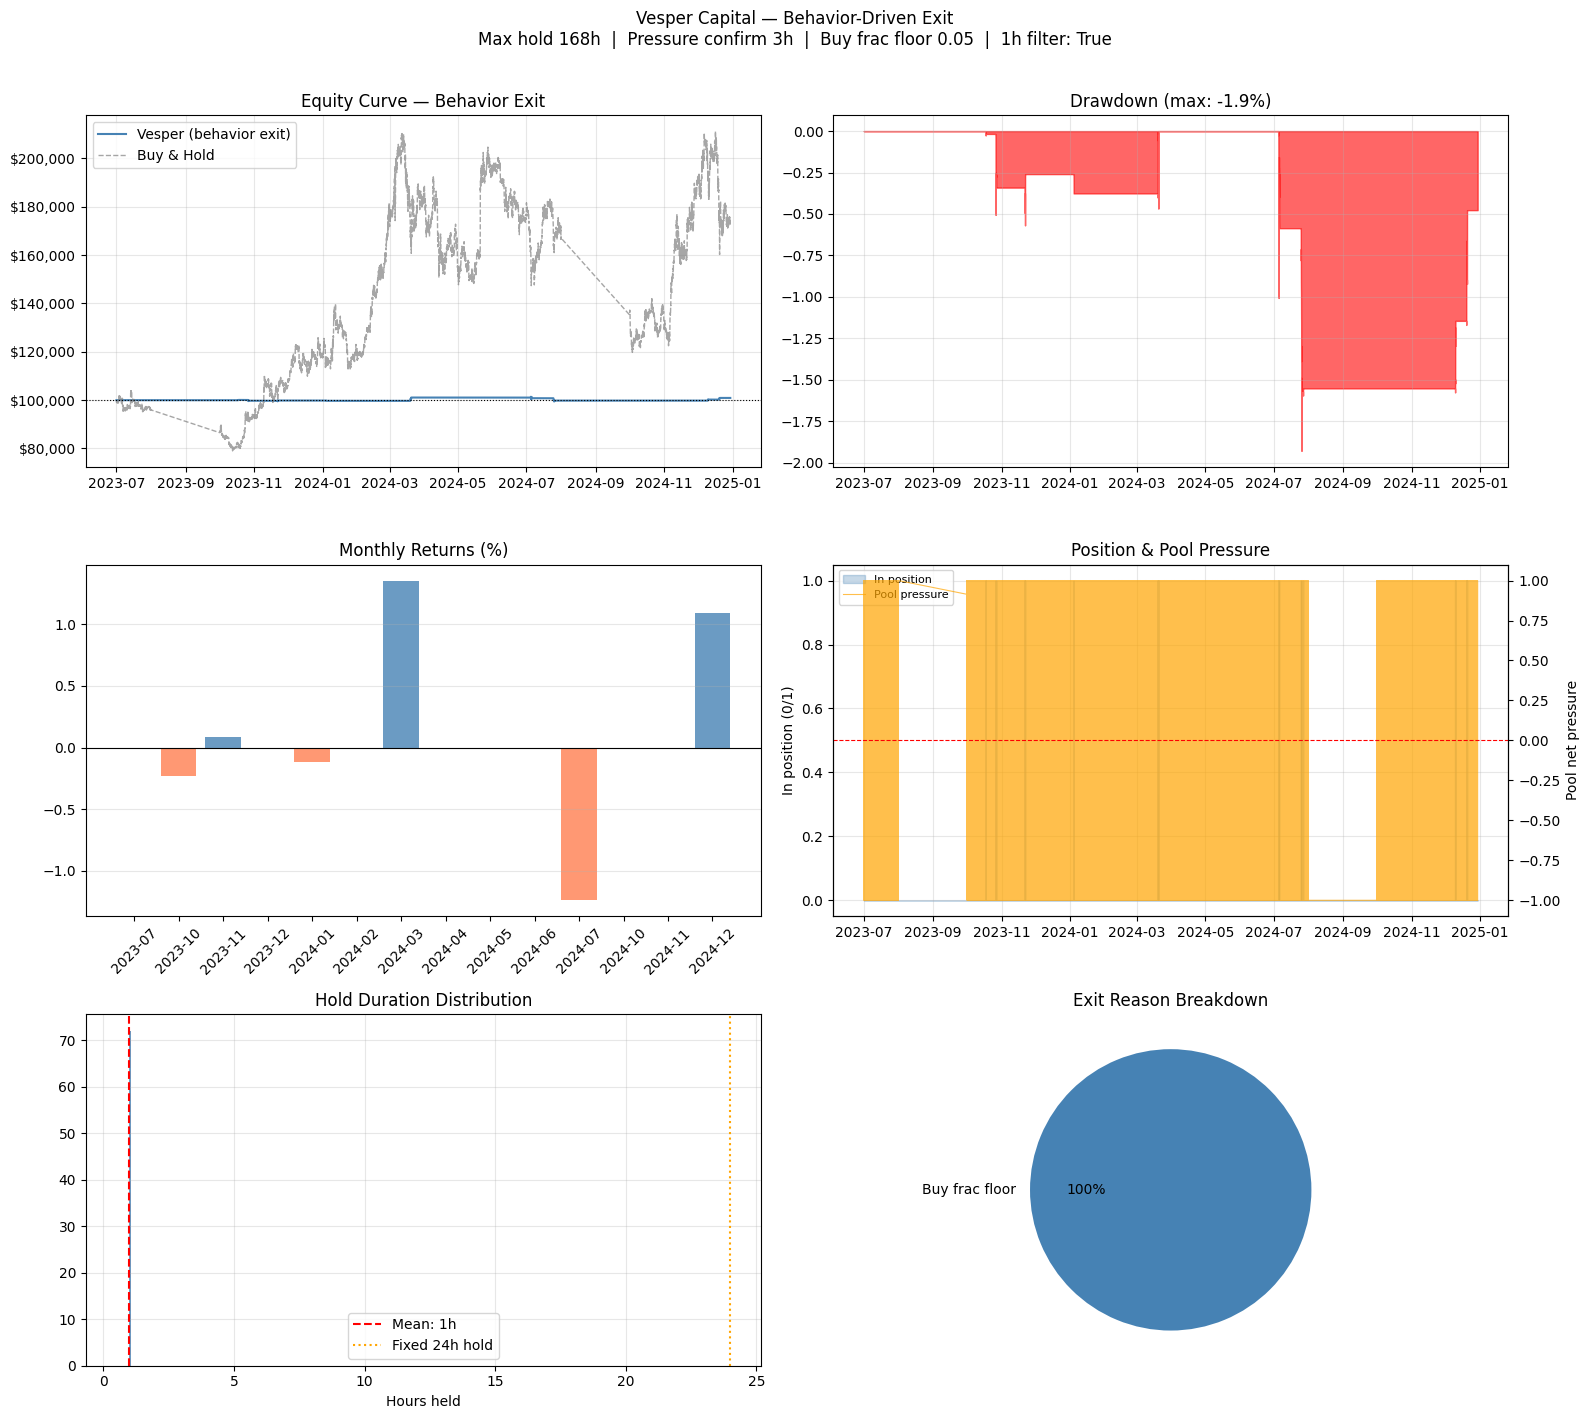

In [21]:
if len(beh_eq) > 0:
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))

    # 1. Equity curve
    ax = axes[0, 0]
    ax.plot(beh_eq['timestamp'], beh_eq['capital'],
            color='steelblue', linewidth=1.5, label='Vesper (behavior exit)')
    ax.plot(beh_eq['timestamp'], bah_series,
            color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Buy & Hold')
    ax.axhline(INITIAL_CAPITAL, color='black', linewidth=0.8, linestyle=':')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title('Equity Curve — Behavior Exit')
    ax.legend(); ax.grid(alpha=0.3)

    # 2. Drawdown
    ax = axes[0, 1]
    ax.fill_between(beh_eq['timestamp'], drawdown, 0, alpha=0.6, color='red')
    ax.set_title(f'Drawdown (max: {max_drawdown:.1f}%)'); ax.grid(alpha=0.3)

    # 3. Monthly returns
    ax = axes[1, 0]
    colors = ['steelblue' if r >= 0 else 'coral' for r in monthly['return_pct']]
    ax.bar(monthly['month_period'].astype(str), monthly['return_pct'],
           color=colors, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Monthly Returns (%)')
    ax.tick_params(axis='x', rotation=45); ax.grid(alpha=0.3, axis='y')

    # 4. Position and pool pressure over time
    ax = axes[1, 1]
    ax2 = ax.twinx()
    ax.fill_between(beh_eq['timestamp'], beh_eq['in_position'],
                    alpha=0.3, color='steelblue', label='In position')
    ax2.plot(beh_eq['timestamp'], beh_eq['pool_pressure'],
             color='orange', linewidth=0.8, alpha=0.7, label='Pool pressure')
    ax2.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_title('Position & Pool Pressure')
    ax.set_ylabel('In position (0/1)')
    ax2.set_ylabel('Pool net pressure')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
    ax.grid(alpha=0.3)

    # 5. Hold duration distribution
    ax = axes[2, 0]
    if len(exits) > 0:
        ax.hist(exits['hours_held'].clip(upper=MAX_HOLD_HOURS),
                bins=20, color='steelblue', alpha=0.8)
        ax.axvline(exits['hours_held'].mean(), color='red',
                   linestyle='--', label=f"Mean: {exits['hours_held'].mean():.0f}h")
        ax.axvline(24, color='orange', linestyle=':', label='Fixed 24h hold')
        ax.set_title('Hold Duration Distribution')
        ax.set_xlabel('Hours held')
        ax.legend(); ax.grid(alpha=0.3)

    # 6. Exit reason pie chart
    ax = axes[2, 1]
    if len(exits) > 0:
        reason_counts = exits['exit_reason'].value_counts()
        # Simplify labels
        simplified = {}
        for k, v in reason_counts.items():
            if 'time_stop' in str(k):
                simplified['Time stop'] = simplified.get('Time stop', 0) + v
            elif 'pressure_reversal' in str(k):
                simplified['Pressure reversal'] = simplified.get('Pressure reversal', 0) + v
            elif 'buy_fraction' in str(k):
                simplified['Buy frac floor'] = simplified.get('Buy frac floor', 0) + v
            else:
                simplified[str(k)] = simplified.get(str(k), 0) + v
        ax.pie(simplified.values(), labels=simplified.keys(),
               autopct='%1.0f%%', colors=['steelblue','coral','orange','gray'])
        ax.set_title('Exit Reason Breakdown')

    plt.suptitle(
        f'Vesper Capital — Behavior-Driven Exit\n'
        f'Max hold {MAX_HOLD_HOURS}h  |  '
        f'Pressure confirm {PRESSURE_CONFIRM_HOURS}h  |  '
        f'Buy frac floor {EXIT_PRESSURE_FLOOR}  |  '
        f'1h filter: {USE_1H_FILTER}',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()


## 7e. Comparison: fixed hold vs behavior exit

In [22]:
# ============================================================
# Compare fixed-hold vs behavior-driven exit side by side
# ============================================================
print("=" * 65)
print("COMPARISON: FIXED 24H HOLD vs BEHAVIOR-DRIVEN EXIT")
print("=" * 65)
print()

# Fixed hold results (from earlier cells)
fixed_final  = equity_df['capital'].iloc[-1] if 'equity_df' in dir() and len(equity_df) > 0 else None
fixed_return = (fixed_final / INITIAL_CAPITAL - 1) * 100 if fixed_final else None
fixed_entries = len(trade_log_df[trade_log_df['type']=='ENTRY']) if 'trade_log_df' in dir() else None
fixed_tc      = trade_log_df['tc'].sum() if 'trade_log_df' in dir() else None

beh_final   = beh_eq['capital'].iloc[-1] if len(beh_eq) > 0 else None
beh_return  = (beh_final / INITIAL_CAPITAL - 1) * 100 if beh_final else None
beh_entries = len(entries)
beh_tc      = beh_eq['tc'].sum()
beh_hold    = exits['hours_held'].mean() if len(exits) > 0 else None

print(f"{'Metric':<35} {'Fixed 24h Hold':>16} {'Behavior Exit':>16}")
print("-" * 68)

def fmt(v, fmt_str):
    return fmt_str.format(v) if v is not None else "N/A"

print(f"{'Total return':<35} {fmt(fixed_return, '{:>+15.2f}%')} {fmt(beh_return, '{:>+15.2f}%')}")
print(f"{'Buy & hold return':<35} {fmt(bah_return, '{:>+15.2f}%')} {fmt(bah_return, '{:>+15.2f}%')}")
print(f"{'Final capital':<35} {fmt(fixed_final, '${:>14,.2f}')} {fmt(beh_final, '${:>14,.2f}')}")
print(f"{'Entries':<35} {fmt(fixed_entries, '{:>16}'):>16} {fmt(beh_entries, '{:>16}'):>16}")
print(f"{'Transaction costs':<35} {fmt(fixed_tc, '${:>14,.2f}')} {fmt(beh_tc, '${:>14,.2f}')}")
print(f"{'Mean hold duration':<35} {'24h (fixed)':>16} {fmt(beh_hold, '{:>13.1f}h')}")
print()

if beh_return is not None and fixed_return is not None:
    delta = beh_return - fixed_return
    print(f"Behavior exit improvement: {delta:+.2f}%")
    if delta > 2:
        print("✓ Behavior-driven exit materially outperforms fixed hold")
    elif delta > 0:
        print("~ Behavior-driven exit modestly outperforms fixed hold")
    else:
        print("✗ Fixed hold outperforms behavior-driven exit")
        print("  Consider tuning exit parameters (MAX_HOLD_HOURS, PRESSURE_CONFIRM_HOURS)")


COMPARISON: FIXED 24H HOLD vs BEHAVIOR-DRIVEN EXIT

Metric                                Fixed 24h Hold    Behavior Exit
--------------------------------------------------------------------
Total return                                  +4.78%           +0.92%
Buy & hold return                            +74.68%          +74.68%
Final capital                       $    104,780.02 $    100,924.60
Entries                                           15               72
Transaction costs                   $        771.30 $      2,432.53
Mean hold duration                       24h (fixed)           1.0h

Behavior exit improvement: -3.86%
✗ Fixed hold outperforms behavior-driven exit
  Consider tuning exit parameters (MAX_HOLD_HOURS, PRESSURE_CONFIRM_HOURS)


## 8. Performance metrics

In [ ]:
eq = equity_df.copy()

# Buy & hold over same period
bah_capital = pd.Series(INITIAL_CAPITAL, index=[0])
close_series = eq['close'].values
bah_vals = [INITIAL_CAPITAL]
for i in range(1, len(close_series)):
    ret = (close_series[i] - close_series[i-1]) / close_series[i-1]
    bah_vals.append(bah_vals[-1] * (1 + ret))
bah_series = pd.Series(bah_vals, index=eq.index)

# Metrics
final_capital  = eq['capital'].iloc[-1]
total_return   = (final_capital / INITIAL_CAPITAL - 1) * 100
bah_return     = (bah_series.iloc[-1] / INITIAL_CAPITAL - 1) * 100
rolling_max    = eq['capital'].cummax()
drawdown       = (eq['capital'] - rolling_max) / rolling_max * 100
max_drawdown   = drawdown.min()

# Trade-level metrics
completed = trade_log_df[trade_log_df['type']=='EXIT']
win_rate   = (completed['pnl'] > 0).mean() if len(completed) > 0 else 0
avg_win    = completed.loc[completed['pnl']>0,'pnl'].mean() if (completed['pnl']>0).any() else 0
avg_loss   = completed.loc[completed['pnl']<0,'pnl'].mean() if (completed['pnl']<0).any() else 0
pf_denom   = abs(completed.loc[completed['pnl']<0,'pnl'].sum())
profit_factor = abs(completed.loc[completed['pnl']>0,'pnl'].sum()) / pf_denom if pf_denom > 0 else np.inf

# Sharpe on completed trades
if len(completed) > 1:
    trade_rets = completed['pnl'] / completed['deployed'] * 100
    sharpe = trade_rets.mean() / trade_rets.std() * np.sqrt(365 * 24 / HOLD_HOURS) if trade_rets.std() > 0 else 0
else:
    sharpe = 0

# Monthly breakdown
eq['month_period'] = eq['timestamp'].dt.to_period('M')
monthly = eq.groupby('month_period').agg(
    start_cap  = ('capital', 'first'),
    end_cap    = ('capital', 'last'),
    n_signals  = ('long_signal', 'sum'),
    total_pnl  = ('pnl', 'sum'),
    total_tc   = ('tc', 'sum'),
).reset_index()
monthly['return_pct'] = (monthly['end_cap'] / monthly['start_cap'] - 1) * 100

print("=" * 60)
print("VESPER CAPITAL — PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Period: {eq['timestamp'].min().date()} to {eq['timestamp'].max().date()}")
print(f"Strategy: {'Long/Short' if USE_SHORT else 'Long/Flat'}")
print()
print(f"{'Total return:':<35} {total_return:>10.2f}%")
print(f"{'Buy & hold return:':<35} {bah_return:>10.2f}%")
print(f"{'Outperformance vs B&H:':<35} {total_return - bah_return:>+10.2f}%")
print(f"{'Final capital:':<35} ${final_capital:>12,.2f}")
print(f"{'Max drawdown:':<35} {max_drawdown:>10.2f}%")
print(f"{'Sharpe (trade level):':<35} {sharpe:>10.3f}")
print(f"{'Win rate (completed trades):':<35} {win_rate:>10.1%}")
print(f"{'Avg winning trade:':<35} ${avg_win:>10,.2f}")
print(f"{'Avg losing trade:':<35} ${avg_loss:>10,.2f}")
print(f"{'Profit factor:':<35} {profit_factor:>10.2f}x")
print(f"{'Total transaction costs:':<35} ${eq['tc'].sum():>10,.2f}")
print(f"{'Total completed trades:':<35} {len(completed):>10}")
print()
print("Monthly breakdown:")
print(monthly[['month_period','return_pct','n_signals','total_pnl','total_tc'
               ]].to_string(index=False))


# Conviction bucket analysis
if 'conviction' in trade_log_df.columns:
    completed = exits.copy()
    if len(completed) > 0:
        completed['bucket'] = pd.cut(
            completed['conviction'],
            bins=[0, 0.25, 0.5, 0.75, 1.01],
            labels=['Low (0-25%)', 'Med (25-50%)', 'High (50-75%)', 'Very High (75-100%)'],
            include_lowest=True
        )
        ca = completed.groupby('bucket').agg(
            n_trades  = ('pnl', 'count'),
            mean_pnl  = ('pnl', 'mean'),
            win_rate  = ('pnl', lambda x: (x>0).mean()),
            total_pnl = ('pnl', 'sum'),
        ).reset_index()
        print()
        print("Conviction bucket analysis:")
        print(ca.round(2).to_string(index=False))


## 9. Visualization

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Equity curve
ax = axes[0, 0]
ax.plot(eq['timestamp'], eq['capital'],
        color='steelblue', linewidth=1.5, label='Vesper Capital')
ax.plot(eq['timestamp'], bah_series,
        color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Buy & Hold')
ax.axhline(INITIAL_CAPITAL, color='black', linewidth=0.8, linestyle=':')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Equity Curve')
ax.legend()
ax.grid(alpha=0.3)

# 2. Drawdown
ax = axes[0, 1]
ax.fill_between(eq['timestamp'], drawdown, 0, alpha=0.6, color='red')
ax.set_title(f'Drawdown (max: {max_drawdown:.1f}%)')
ax.set_ylabel('Drawdown (%)')
ax.grid(alpha=0.3)

# 3. Monthly returns
ax = axes[1, 0]
colors = ['steelblue' if r >= 0 else 'coral' for r in monthly['return_pct']]
ax.bar(monthly['month_period'].astype(str), monthly['return_pct'],
       color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Returns (%)')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

# 4. Open positions over time
ax = axes[1, 1]
ax.fill_between(eq['timestamp'], eq['n_open'], alpha=0.5, color='steelblue')
ax.set_title('Number of Open Positions')
ax.set_ylabel('N open')
ax.grid(alpha=0.3)

# 5. Trade PnL distribution
ax = axes[2, 0]
if len(completed) > 0:
    wins   = completed[completed['pnl'] > 0]['pnl']
    losses = completed[completed['pnl'] < 0]['pnl']
    if len(losses) > 0:
        ax.hist(losses.values, bins=20, alpha=0.6, color='coral',
                label=f'Losses (n={len(losses)})')
    if len(wins) > 0:
        ax.hist(wins.values, bins=20, alpha=0.6, color='steelblue',
                label=f'Wins (n={len(wins)})')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title('Completed Trade PnL Distribution')
    ax.set_xlabel('PnL ($)')
    ax.legend()
    ax.grid(alpha=0.3)

# 6. Monthly PnL
ax = axes[2, 1]
colors2 = ['steelblue' if p >= 0 else 'coral' for p in monthly['total_pnl']]
ax.bar(monthly['month_period'].astype(str), monthly['total_pnl'],
       color=colors2, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly PnL ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.suptitle(
    f'Vesper Capital — {"Long/Short" if USE_SHORT else "Long/Flat"} Model\n'
    f'${INITIAL_CAPITAL:,.0f} initial  |  {POSITION_PCT*100:.0f}% position sizing  |  '
    f'{TRANSACTION_COST*100:.1f}% round-trip cost  |  {HOLD_HOURS}h hold',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


## 10. Save results

In [ ]:
equity_df.to_csv(COMBINED_RESULTS_CSV, index=False)
trade_log_df.to_csv(COMBINED_RESULTS_CSV.replace('combined_model', 'trade_log'), index=False)
print(f"Results saved: {COMBINED_RESULTS_CSV}")
print(f"Trade log saved: {COMBINED_RESULTS_CSV.replace('combined_model', 'trade_log')}")
print()
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Total return:     {total_return:.2f}%")
print(f"vs Buy & Hold:    {bah_return:.2f}%")
print(f"Outperformance:   {total_return - bah_return:+.2f}%")
print(f"Max drawdown:     {max_drawdown:.2f}%")
print(f"Profit factor:    {profit_factor:.2f}x")
print(f"Win rate:         {win_rate:.1%}")
print(f"Completed trades: {len(completed)}")
print(f"Final capital:    ${final_capital:,.2f}")


In [33]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path('/home/colin/projects/blockchain_alpha')

# ── Check accepted wallet balance store ───────────────────────
accepted_bal = BASE_DIR / 'data/balance_store_accepted_wallets.csv'
if accepted_bal.exists():
    df = pd.read_csv(accepted_bal)
    df['date']    = pd.to_datetime(df['date'], format='mixed').dt.floor('h')
    df['address'] = df['address'].str.lower().str.strip()
    
    # Deduplicate
    df = (df.sort_values(['address','date','block_number'])
            .groupby(['address','date'], as_index=False).tail(1)
            .reset_index(drop=True))
    
    n_hours   = (pd.Timestamp('2024-12-31') - pd.Timestamp('2023-01-01')).days * 24
    n_wallets = df['address'].nunique()
    coverage  = len(df) / (n_wallets * n_hours) * 100
    
    print(f"Accepted wallet balance store:")
    print(f"  Rows:             {len(df):,}")
    print(f"  Unique wallets:   {n_wallets}")
    print(f"  Date range:       {df['date'].min()} to {df['date'].max()}")
    print(f"  Coverage:         {coverage:.1f}%")
    print()
    
    # Per-wallet row counts — flag any with low coverage
    per_wallet = df.groupby('address').size().sort_values()
    low_cov    = per_wallet[per_wallet < n_hours * 0.9]
    print(f"  Wallets with <90% coverage: {len(low_cov)}")
    if len(low_cov) > 0:
        print(low_cov.to_string())
else:
    print(f"File not found: {accepted_bal}")
    print("Fetch may not have completed yet.")

print()

# ── Check combined balance store ──────────────────────────────
combined_bal = BASE_DIR / 'data/balance_store_hourly_combined.csv'
if combined_bal.exists():
    df_c = pd.read_csv(combined_bal, usecols=['address','date'])
    df_c['address'] = df_c['address'].str.lower().str.strip()
    
    print(f"Combined balance store:")
    print(f"  Rows:           {len(df_c):,}")
    print(f"  Unique wallets: {df_c['address'].nunique()}")
    print(f"  (top-200 had 200 wallets, combined should have ~268)")
else:
    print(f"Combined store not found: {combined_bal}")
    print("Run cell 5 in accepted_wallet_fetch.ipynb to create it.")

Accepted wallet balance store:
  Rows:             1,979,873
  Unique wallets:   113
  Date range:       2023-01-01 00:00:00 to 2024-12-31 00:00:00
  Coverage:         100.0%

  Wallets with <90% coverage: 0

Combined store not found: /home/colin/projects/blockchain_alpha/data/balance_store_hourly_combined.csv
Run cell 5 in accepted_wallet_fetch.ipynb to create it.
